# Stage 4: Implementing proposed approach

# 1️⃣ Uploading Data

```
1. dontpatronizeme_pcl
2. Dev Set
3. Trian Set
4. Test Set
```



In [1]:
#Get the dataset (dontpatronizeme_pcl.tsv)
!wget -q https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv
!head -2 dontpatronizeme_pcl.tsv

------------------------------------------------------ DISCLAIMER ------------------------------------------------------
The Don’t Patronize Me! dataset has been created for research purposes. Patronizing and Condescending Language (PCL) towards vulnerable communities is understood in this dataset as a commonly used, generally unconscious and well intended writing style. We consider that the authors of the paragraphs included in this dataset do not intend any harm towards the vulnerable communities they talk about and we reckon that their objective is to support these communities and/or raise awareness towards difficult situations. The Don’t Patronize Me! dataset can only be used for research purposes.


In [2]:
#Get the dataset (train and dev)
!wget -q https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/train_semeval_parids-labels.csv
!wget -q https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/dev_semeval_parids-labels.csv

!head -2 train_semeval_parids-labels.csv
!head -2 dev_semeval_parids-labels.csv

par_id,label
4341,"[1, 0, 0, 1, 0, 0, 0]"
par_id,label
4046,"[1, 0, 0, 1, 0, 0, 0]"


In [3]:
#Get the dataset (test set)
!wget -q https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST/task4_test.tsv

!head -2 task4_test.tsv

t_0	@@7258997	vulnerable	us	In the meantime , conservatives are working to weaken Clinton and drive down her numbers in early voting states , where she is increasingly vulnerable . They are , in effect , doing Sanders 's dirty work for him while he avoids scrutiny .
t_1	@@16397324	women	pk	In most poor households with no education children are a matter of routine . The house maid industry is a sorry tale of dysfunctional families . The norm of these families is to make their women and children work while the men do not work , are on drugs , and either just abuse their wives or produce more children .


In [4]:
# Check the Data is Downloaded
!ls -lh
# Remover the duplicate
# !rm task4_test.tsv
# !rm task4_test.tsv.1

total 451M
drwxr-sr-x.  2 ska24 hpc-ocamburu 4.0K Mar  4 12:15  BestModel
-rw-r--r--.  1 ska24 hpc-ocamburu 422M Mar  4 12:16  BestModel.zip
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 11:06  dev_semeval_parids-labels.csv
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 11:36  dev_semeval_parids-labels.csv.1
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 11:41  dev_semeval_parids-labels.csv.2
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 11:41  dev_semeval_parids-labels.csv.3
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 11:42  dev_semeval_parids-labels.csv.4
-rw-r--r--.  1 ska24 hpc-ocamburu  60K Mar  4 12:47  dev_semeval_parids-labels.csv.5
-rw-r--r--.  1 ska24 hpc-ocamburu 4.1K Mar  4 12:40  dev.txt
-rw-r--r--.  1 ska24 hpc-ocamburu 3.0M Mar  4 11:05  dontpatronizeme_pcl.tsv
-rw-r--r--.  1 ska24 hpc-ocamburu 3.0M Mar  4 11:06  dontpatronizeme_pcl.tsv.1
-rw-r--r--.  1 ska24 hpc-ocamburu 3.0M Mar  4 11:36  dontpatronizeme_pcl.tsv.2
-rw-r--r--.  1 ska24 hpc-ocamburu 3.0M Mar  4 11:36  do

# 2️⃣ Basic Dependencies
```
1. transformer model
2. Basic Imports
```


In [5]:
!pip install transformers datasets scikit-learn

  Using cached transformers-5.2.0-py3-none-any.whl (10.4 MB)
  Using cached datasets-4.6.1-py3-none-any.whl (520 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
  Using cached huggingface_hub-1.5.0-py3-none-any.whl (596 kB)
  Using cached regex-2026.2.28-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (800 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Using cached typer_slim-0.24.0-py3-none-any.whl (3.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (507 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached filelock-3.25.0-py3-none-any.whl (26 kB)
  Using cached pyarrow-23.0.1-cp311-cp311-manylinux_2_28_x86_64.whl (47.6 MB)
  Using cached dill-0.4.0-py3-none-any.whl (119 kB)
  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
  U

In [6]:
!pip install pandas
!pip install numpy
!pip install torch
!pip install torch.utils.data
!pip install sklearn.metrics
!pip install transformers
!pip install warnings

  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/opt/jupyter/lib64/python3.11/site-packages/pandas'
Check the permissions.


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached torch-2.10.0-cp311-cp311-manylinux_2_28_x86_64.whl (915.6 MB)
  Using cached filelock-3.25.0-py3-none-any.whl (26 kB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
  Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
  Using cached cuda_bindings-12.9.4-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.2 MB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl (88.0 MB)
  Us

In [7]:
import pandas as pd
import numpy as np
import torch
import re
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, precision_recall_curve
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

/rds/general/user/ska24/home/miniforge3/envs/pcl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# define the device to use it
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# 3️⃣ Data Processing

In [9]:
df = pd.read_csv( 'dontpatronizeme_pcl.tsv', sep='\t', header=None, names=['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'], quoting=3,)

In [10]:
# Clean the data from NA and Missing Data
df = df.dropna(subset=['text'])

In [11]:
# Due to EDA analysis of 469 paragraphs containing HTML artifacts
def clean_text(text):
    text = str(text)
    text = text.replace('&amp;', '&')
    text = text.replace('&lt;', '<')
    text = text.replace('&gt;', '>')
    text = text.replace('\\n', ' ')
    text = text.replace('\\t', ' ')
    text = re.sub(r'<[^>]+>', '', text)  # remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespace
    return text

df['text'] = df['text'].apply(clean_text)

In [12]:
# make sure that the label are int type -> mitigating the error
df['label'] = df['label'].astype(int)
# make the conversion to 0: No PCL and 1: PCL
df['binary_label'] = df['label'].apply(lambda x: 1 if x >= 2 else 0)

Now lets get the split of train / dev in dataframe

In [13]:
train_IDs = pd.read_csv('train_semeval_parids-labels.csv')
dev_IDs = pd.read_csv('dev_semeval_parids-labels.csv')

In [14]:
#chceing the match between the train/dev set with the
print(train_IDs['par_id'].dtype, df['par_id'].dtype)
print(dev_IDs['par_id'].dtype, df['par_id'].dtype)

int64 object
int64 object


In [15]:
# convert df['par_id'] to int64
df['par_id'] = df['par_id'].astype('int64')

Checking with the initial numbers:

8375 + 2093 = 10,468

In [16]:
train_df = df[df['par_id'].isin(train_IDs['par_id'])].reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_IDs['par_id'])].reset_index(drop=True)

print(f"Train Set: {len(train_df)}\nDev Set: {len(dev_df)}")

Train Set: 8375
Dev Set: 2093


# 4️⃣ Model Development

## Techniques 1: Class Weighted loss

In [17]:
# Check the classes counts
noPCL_n = (train_df['binary_label']==0).sum()
PCL_n = (train_df['binary_label']==1).sum()

print(f'No PCL: {noPCL_n}\nPCL: {PCL_n}')
print(f'PCL% = {PCL_n/(PCL_n+noPCL_n)*100}')

No PCL: 7581
PCL: 794
PCL% = 9.480597014925374


In [18]:
# compute the weight according to this formula weight = total_samples / (num_classes × count_of_a_class)

weight_noPCL = len(train_df)/ (2*noPCL_n)
weight_PCL = len(train_df)/ (2*PCL_n)

print(f'No PCL: {weight_noPCL}\nPCL: {weight_PCL}')

No PCL: 0.5523677615090358
PCL: 5.273929471032746


In [20]:
#convert it to a tensor to be used in the transformer
weights_tensor = torch.tensor([weight_noPCL,weight_PCL],dtype=torch.float32).to(device)

## Technique 2: Allow for long PCL paragraph

by making the window length max = 512

In [21]:
class PCLDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = self.labels[index]

        token = self.tokenizer(
                  text,
                  add_special_tokens=True,
                  truncation=True,
                  max_length=self.max_length,
                  padding='max_length',
                  return_tensors='pt'
                )

        input_ids = token['input_ids'].squeeze()
        mask = token['attention_mask'].squeeze()
        label = torch.tensor(label, dtype=torch.long)

        return { 'input_ids':input_ids,
                 'mask':mask,
                 'label':label}

In [22]:
# Baseline Model
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

### Train/Validation Split

Split the training set into 80% training and 20% internal validation.


In [23]:
from sklearn.model_selection import train_test_split

split_train_texts, split_val_texts, split_train_labels, split_val_labels = train_test_split(
    train_df['text'].tolist(),
    train_df['binary_label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df['binary_label'].tolist()
)

print(f'Train split: {len(split_train_texts)}\nVal split: {len(split_val_texts)}')

# compute class weights from training split only
noPCL_split = sum(1 for l in split_train_labels if l == 0)
PCL_split = sum(1 for l in split_train_labels if l == 1)
weight_noPCL_split = len(split_train_labels) / (2 * noPCL_split)
weight_PCL_split = len(split_train_labels) / (2 * PCL_split)
weights_tensor_split = torch.tensor([weight_noPCL_split, weight_PCL_split], dtype=torch.float32).to(device)

print(f'No PCL weight: {weight_noPCL_split:.4f}\nPCL weight: {weight_PCL_split:.4f}')

Train split: 6700
Val split: 1675
No PCL weight: 0.5523
PCL weight: 5.2756


In [24]:
batch_size = 16
split_train_dataset = PCLDataset(split_train_texts, split_train_labels, tokenizer)
split_val_dataset = PCLDataset(split_val_texts, split_val_labels, tokenizer)

split_train_loader = DataLoader(split_train_dataset, batch_size=batch_size, shuffle=True)
split_val_loader = DataLoader(split_val_dataset, batch_size=batch_size, shuffle=False)

## Model Setup & Training

In [25]:
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model.to(device)

epochs = 4
lr = 2e-5

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
total_steps = len(split_train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor_split)

Loading weights: 100%|██████████| 197/197 [00:02<00:00, 86.91it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]               
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

## Model Training & evaluation

In [26]:
def train_per_epoch (model,loader, optimizer,scheduler,loss_fn):
      #activate the training mode
      model.train()

      loss_overall = 0.0

      for batch in loader:
        input_ids = batch['input_ids'].to(device)
        mask = batch['mask'].to(device)
        label = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask=mask).logits

        loss = loss_fn(outputs, label)

        #backprobagation
        loss.backward()

        #trick to prevent grad from explode
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        loss_overall += loss.item()

      return loss_overall / len(loader)

In [27]:
def eval (model,loader):
    #actuivate evaluation mode
    model.eval()

    # Acculimilate related result
    pred_list = []
    prob_list = []
    labels_list = []

    with torch.no_grad():
        for batch in loader:
          input_ids = batch['input_ids'].to(device)
          mask = batch['mask'].to(device)
          label = batch['label'].to(device)

          outputs = model(input_ids, attention_mask=mask)

          probs = torch.softmax(outputs.logits, dim=1)[:,1] # Only PCL which we care about

          predection = torch.argmax(outputs.logits, dim=1)


          pred_list.extend(predection.cpu().numpy())
          prob_list.extend(probs.cpu().numpy())
          labels_list.extend(label.cpu().numpy())

    return np.array(pred_list), np.array(prob_list), np.array(labels_list)


## Train Loop (on 80% split)

In [28]:
for e in range(epochs):
  print(f"Epoch {e+1}/{epochs}")
  avg_loss = train_per_epoch(model,split_train_loader,optimizer,scheduler,loss_fn)

  y_pred , y_prob, y_true = eval(model,split_val_loader)
  current_f1 = f1_score(y_true, y_pred, pos_label=1)

  print(f"  Train Loss: {avg_loss:.4f}")
  print(f"  Val F1: {current_f1:.4f}")

print('Training Done')

Epoch 1/4
  Train Loss: 0.6390
  Val F1: 0.4950
Epoch 2/4
  Train Loss: 0.4653
  Val F1: 0.5251
Epoch 3/4
  Train Loss: 0.3798
  Val F1: 0.5641
Epoch 4/4
  Train Loss: 0.2207
  Val F1: 0.5651
Training Done


## Decision Threshold Tuning (on internal validation set)

In [29]:
y_pred, y_prob, y_true = eval(model, split_val_loader)

thresholds = np.arange(0.1, 0.9, 0.01)
threshold_best = 0.5
f1_best = 0.0

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    f1_t = f1_score(y_true, preds_t, pos_label=1)

    if f1_t > f1_best:
        f1_best = f1_t
        threshold_best = t

print('Best Threshold: ', threshold_best)
print('Best F1 score: ', f1_best)

Best Threshold:  0.48999999999999977
Best F1 score:  0.5650793650793651


In [30]:
print("RETRAINING ON FULL TRAIN SET")

# create full train dataset and loader
full_train_dataset = PCLDataset(train_df['text'].tolist(), train_df['binary_label'].tolist(), tokenizer)
full_train_loader = DataLoader(full_train_dataset, batch_size=batch_size, shuffle=True)

# create dev dataset and loader (held out, never used for training)
dev_dataset = PCLDataset(dev_df['text'].tolist(), dev_df['binary_label'].tolist(), tokenizer)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
total_steps = len(full_train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights_tensor)

for e in range(epochs):
    avg_loss = train_per_epoch(model, full_train_loader, optimizer, scheduler, loss_fn)
    print(f"Epoch {e+1}/{epochs} | Loss: {avg_loss:.4f}")

print('Retraining Done')

RETRAINING ON FULL TRAIN SET


Loading weights: 100%|██████████| 197/197 [00:02<00:00, 87.02it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]               
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch 1/4 | Loss: 0.6217
Epoch 2/4 | Loss: 0.5071
Epoch 3/4 | Loss: 0.3990
Epoch 4/4 | Loss: 0.2806
Retraining Done


In [31]:
# Save Model
model.save_pretrained('./BestModel')
tokenizer.save_pretrained('./BestModel')
print("Model saved")

# Zip for download
!rm -f BestModel.zip
!zip -r BestModel.zip BestModel/

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.13it/s]


Model saved
  adding: BestModel/ (stored 0%)
 (deflated 11%)odel/model.safetensors
  adding: BestModel/config.json (deflated 50%)
  adding: BestModel/tokenizer_config.json (deflated 50%)
 (deflated 82%)odel/tokenizer.json


#

---



# Stage 5: Evalaution


## 1️⃣ Stage 5.1: Gloabal Evalution

In [32]:
# Evaluate on held-out dev set (UNBIASED)
y_pred_final, y_prob_final, y_true_final = eval(model, dev_loader)
final_dev_pred = (y_prob_final >= threshold_best).astype(int)
dev_f1 = f1_score(y_true_final, final_dev_pred, pos_label=1)

print(f"Dev F1 (threshold={threshold_best:.2f}): {dev_f1:.4f}")
print(classification_report(y_true_final, final_dev_pred, target_names=['No PCL', 'PCL']))

Dev F1 (threshold=0.49): 0.6122
              precision    recall  f1-score   support

      No PCL       0.96      0.96      0.96      1894
         PCL       0.62      0.60      0.61       199

    accuracy                           0.93      2093
   macro avg       0.79      0.78      0.79      2093
weighted avg       0.93      0.93      0.93      2093



In [34]:
print('Final Performance Report')
print(f"y_pred sample: {y_pred_final[:10]}")
print(f"y_prob sample: {y_prob_final[:10]}")
print(f"y_true sample: {y_true_final[:10]}")
print(f"y_pred unique values: {np.unique(y_pred_final)}")
print(f"y_prob unique values range: {y_prob_final.min():.3f} to {y_prob_final.max():.3f}")

Final Performance Report
y_pred sample: [0 0 0 1 0 1 1 1 1 0]
y_prob sample: [0.00154097 0.00676545 0.0126006  0.9974947  0.00591234 0.995073
 0.997505   0.99747854 0.99465936 0.03059547]
y_true sample: [1 1 1 1 1 1 1 1 1 1]
y_pred unique values: [0 1]
y_prob unique values range: 0.001 to 0.998


In [35]:
# save the result
np.savetxt('dev.txt', final_dev_pred, fmt='%d')
print(f"dev.txt saved: {len(final_dev_pred)} predictions")

dev.txt saved: 2093 predictions


For Test set:

In [36]:
# test predection

test_df = pd.read_csv('task4_test.tsv',sep='\t', header=None, names=['par_id', 'art_id', 'keyword', 'country_code', 'text'], quoting=3,)
test_df = test_df.dropna(subset=['text'])
test_df['text'] = test_df['text'].apply(clean_text)

test_dataset = PCLDataset(test_df['text'].tolist(), [0]*len(test_df), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

_, test_prob, _ = eval(model, test_loader)
test_preds = (test_prob >= threshold_best).astype(int)

# save result
np.savetxt('test.txt', test_preds, fmt='%d')
print(f"test.txt: {len(test_preds)} lines")

test.txt: 3832 lines


### Download eval files

In [ ]:
# download - use this for Colab
# from google.colab import files
# files.download('dev.txt')
# files.download('test.txt')

# for JupyterLab: right-click the files in the left panel to download

### Verification of the global evaluation

In [37]:
!wc -l test.txt
!wc -l dev.txt
!sort test.txt | uniq -c
!sort dev.txt | uniq -c

3832 test.txt
2093 dev.txt
   3505 0
    327 1
   1900 0
    193 1


# 2️⃣ Stage 5 - Local Evaluation

In [38]:
# related dependicnes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score, classification_report

In [40]:
# get a copy of the dev data
dev_df_err = dev_df.copy()
dev_df_err['label'] = y_true_final
dev_df_err['pred'] = final_dev_pred
dev_df_err['prob'] = y_prob_final

In [41]:
# Define the 4-confusion matrix quadrant
def get_error_type(row):
    if row['label'] == 1 and row['pred'] == 1: return 'TP'
    if row['label'] == 0 and row['pred'] == 0: return 'TN'
    if row['label'] == 1 and row['pred'] == 0: return 'FN' # Missed
    return 'FP' # Wrong Alarm

In [42]:
# Four quadrant
dev_df_err['type'] = 'TN'
dev_df_err.loc[(dev_df_err['label']==1) & (dev_df_err['pred']==1), 'type'] = 'TP'
dev_df_err.loc[(dev_df_err['label']==1) & (dev_df_err['pred']==0), 'type'] = 'FN' # Missed
dev_df_err.loc[(dev_df_err['label']==0) & (dev_df_err['pred']==1), 'type'] = 'FP' #Wrong Alarm

In [43]:
print("Error Analaysis - overall types")
print(dev_df_err['type'].value_counts())

Error Analaysis - overall types
type
TN    1821
TP     120
FN      79
FP      73
Name: count, dtype: int64


## PART A: ERROR ANALYSIS

### Analysis about critical cases: Wrong Alarm and Missed

In [44]:
print("Error Analaysis - Wrong Alarm as PCL")
fp_examples = dev_df_err[dev_df_err['type'] == 'FP'].sort_values('prob', ascending=False)
for i, row in fp_examples.head(7).iterrows():
    print(f"\n  Prob: {row['prob']:.3f} | Keyword: {row['keyword']}")
    print(f"  Text: {row['text'][:200]}...")

Error Analaysis - Wrong Alarm as PCL

  Prob: 0.998 | Keyword: refugee
  Text: In an act of defiance against Hungarian authorities , which had suspended trains to Western Europe , between 1,200 and 2,000 refugees decided to walk from Keleti Station in Budapest to Vienna on Frida...

  Prob: 0.998 | Keyword: poor-families
  Text: Many of the children are from poor families , with parents convinced their children will have a better life at the orphanage , according to Lumos ....

  Prob: 0.997 | Keyword: refugee
  Text: "E-mail Address : * A clinic called "" Hope "" helps a Syrian refugee boy cope with diabetes"...

  Prob: 0.997 | Keyword: in-need
  Text: Jesus begins his teaching in Matthew with the Sermon on the Mount . One group he blesses is those in need of comfort , Blessed are they who mourn , for they will be comforted ( Mt 5:4 ) ....

  Prob: 0.997 | Keyword: hopeless
  Text: """ It beggars belief this scheme has been cobbled together ten weeks from the election when for more t

In [45]:
print("Error Analaysis - Missed")
fn_examples = dev_df_err[dev_df_err['type'] == 'FN'].sort_values('prob', ascending=False)
print('Total Missed PCL example by the model:\t', len(fn_examples))
for i, row in fn_examples.head(7).iterrows():
    print(f"Prob: {row['prob']:.3f} | Keyword: {row['keyword']}")
    print(f"Text: {row['text'][:100]}")

Error Analaysis - Missed
Total Missed PCL example by the model:	 79
Prob: 0.479 | Keyword: poor-families
Text: Real poverty of Britain : Shocking images of UK in the Sixties where poor really meant poor THESE ha
Prob: 0.452 | Keyword: hopeless
Text: While male prisoners in Pakistan also suffer , the female prisoners ' plight is truly worrying . Lik
Prob: 0.372 | Keyword: vulnerable
Text: "Balu , an honest , hard-working labourer , who was injured by army shelling about 1993 leading to p
Prob: 0.261 | Keyword: hopeless
Text: It is seen in recurring violence and continuing degradation of women through stone-age practices suc
Prob: 0.225 | Keyword: women
Text: TurkIt 's heartening to see that measures are being taken in Khyber Pakhtunkhwa ( KP ) to empower wo
Prob: 0.214 | Keyword: immigrant
Text: But if the Supreme Court gives a favorable decision for the president , his immigration program woul
Prob: 0.208 | Keyword: poor-families
Text: However , this success story is not uncommon . It 

Error Distribution by other criteria:


*   keyword
*   text length




 Error distribution by keyword

In [46]:
keyword_errors = dev_df_err.groupby('keyword')['type'].value_counts().unstack(fill_value=0)
print(keyword_errors.to_string())

type           FN  FP   TN  TP
keyword                       
disabled        6   3  177   8
homeless       11  15  168  18
hopeless       11  11  180  15
immigrant       6   0  211   1
in-need         3  11  182  30
migrant         3   0  201   2
poor-families  18  12  140  20
refugee         5  10  165   8
vulnerable      7   9  180  13
women           9   2  217   5


Error distribution by text length

In [47]:
dev_df_err['word_count'] = dev_df_err['text'].apply(lambda x: len(str(x).split()))
length_by_error = dev_df_err.groupby('type')['word_count'].mean()
print(length_by_error.to_string())


type
FN    56.253165
FP    49.945205
TN    46.559033
TP    52.500000


## OTHER LOCAL EVALUATION by Visualizations

Confusion Matrix

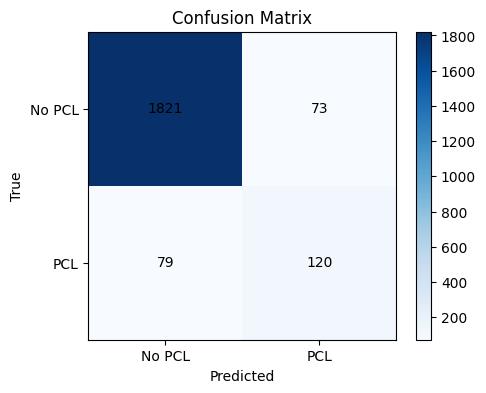

In [48]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_true_final, final_dev_pred)
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['No PCL', 'PCL'])
plt.yticks([0, 1], ['No PCL', 'PCL'])
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()

Precision-Recall Curve

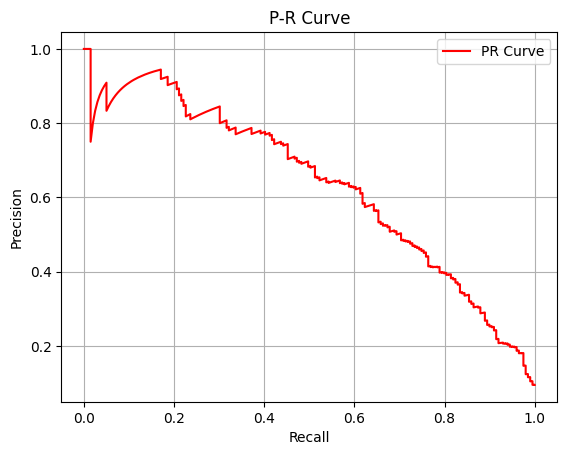

In [49]:
prec, rec, _ = precision_recall_curve(y_true_final, y_prob_final)
plt.figure()
plt.plot(rec, prec, label='PR Curve', color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('P-R Curve')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# F1 vs Threshold check

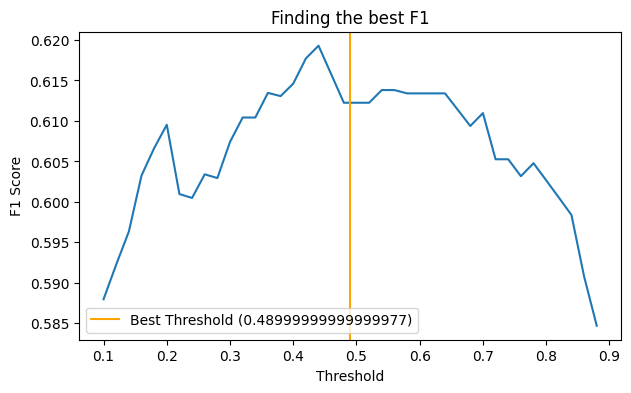

In [51]:
t_range = np.arange(0.1, 0.9, 0.02)
f1_list = []
for t in t_range:
    f1_list.append(f1_score(y_true_final, (y_prob_final >= t).astype(int)))

plt.figure(figsize=(7,4))
plt.plot(t_range, f1_list)
plt.axvline(threshold_best, color='orange', label=f'Best Threshold ({threshold_best})')
plt.title('Finding the best F1')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.show()